# Problem 2.51: Echo Cancellation via Inverse System (Deconvolution)

**Textbook:** Applied Digital Signal Processing (Manolakis & Ingle) - Chapter 2

### Problem Statement:
The digital echo system described in Example 2.8 can be represented by a general impulse response:
$$
h[n] = \sum_{k=0}^{\infty} a_k \delta[n - kD]
$$
To remove these echoes, an inverse system is needed and one implementation of such a system is given by:
$$
g[n] = \sum_{k=0}^{\infty} b_k \delta[n - kD]
$$
such that $h[n] * g[n] = \delta[n]$.

* **(a)** Determine the algebraic equations that the successive $b_k$ must satisfy.
* **(b)** Solve these equations for $b_0, b_1,$ and $b_2$ in terms of $a_k$.
* **(c)** For $a_0 = 1, a_1 = 0.5, a_2 = 0.25$, and all other $a_k$s zero, determine $g[n]$.

In [2]:
%matplotlib inline
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import lfilter


## (a) Derivation of Algebraic Equations for $b_k$
Convolving $h[n]$ with $g[n]$:
$$
\begin{aligned}
h[n] * g[n] &= \left( \sum_{k=0}^{\infty} a_k \delta[n - kD] \right) * \left( \sum_{l=0}^{\infty} b_l \delta[n - lD] \right) \\
&= \sum_{k=0}^{\infty} \sum_{l=0}^{\infty} a_k b_l \delta[n - (k + l)D] \\
&= \sum_{m=0}^{\infty} c_m \delta[n - mD] = \delta[n]
\end{aligned}
$$
where $c_m = \sum_{k=0}^{m} a_k b_{m-k}$ is the discrete convolution of the coefficient sequences $\{a_k\}$ and $\{b_k\}$.

For the result to equal $\delta[n]$:
$$
\begin{cases}
c_0 = a_0 b_0 = 1 & (m = 0) \\
c_m = \sum_{k=0}^{m} a_k b_{m-k} = 0 & (m > 0)
\end{cases}
$$
This yields the recursive relation for successive $b_m$:
$$
b_m = -\frac{1}{a_0} \sum_{k=1}^{m} a_k b_{m-k}, \quad m \ge 1
$$

## (b) Solving for $b_0, b_1,$ and $b_2$
- For $m = 0$:
  $$
  a_0 b_0 = 1 \implies b_0 = \frac{1}{a_0} = a_0^{-1}
  $$
- For $m = 1$:
  $$
  a_0 b_1 + a_1 b_0 = 0 \implies b_1 = -\frac{a_1 b_0}{a_0} = -a_1 a_0^{-2}
  $$
- For $m = 2$:
  $$
  a_0 b_2 + a_1 b_1 + a_2 b_0 = 0 \implies b_2 = \frac{-a_1 b_1 - a_2 b_0}{a_0} = -a_2 a_0^{-2} + a_1^2 a_0^{-3}
  $$

## (c) Determination of $g[n]$ for $a_0 = 1, a_1 = 0.5, a_2 = 0.25$
Given $a_0 = 1, a_1 = 0.5, a_2 = 0.25$ and $a_k = 0$ for $k \ge 3$:
$$
b_0 = 1
$$
$$
b_1 = -0.5
$$
$$
b_2 = -0.25 + (0.5)^2 = 0
$$
For $m \ge 2$, the homogeneous recurrence equation is:
$$
b_m + 0.5 b_{m-1} + 0.25 b_{m-2} = 0
$$
Evaluating the sequence:
- $b_0 = 1 = (0.5)^0$
- $b_1 = -0.5 = -(0.5)^1$
- $b_2 = 0$
- $b_3 = -0.5 b_2 - 0.25 b_1 = 0.125 = (0.5)^3$
- $b_4 = -0.5 b_3 - 0.25 b_2 = -0.0625 = -(0.5)^4$
- $b_5 = -0.5 b_4 - 0.25 b_3 = 0.03125 - 0.03125 = 0$

The closed-form pattern with period 3 is:
$$
b_k = \begin{cases}
(0.5)^k, & k = 3l \\
-(0.5)^k, & k = 3l + 1 \\
0, & k = 3l + 2
\end{cases}, \quad l \in \mathbb{N}_0
$$
Thus:
$$
g[n] = \sum_{k=0}^{\infty} b_k \delta[n - kD]
$$

In [6]:
# Compute first 15 coefficients numerically and verify against closed-form
K = 15
b = np.zeros(K)
b[0] = 1.0
b[1] = -0.5
b[2] = 0.0

for m in range(2, K):
    b[m] = -0.5 * b[m - 1] - 0.25 * b[m - 2]

k_indices = np.arange(K)
b_closed = np.zeros(K)
for k in range(K):
    if k % 3 == 0:
        b_closed[k] = (0.5)**k
    elif k % 3 == 1:
        b_closed[k] = -(0.5)**k
    else:
        b_closed[k] = 0.0

print("k    | b[k] (recursive) | b[k] (closed-form)")
print("-" * 44)
for k in range(K):
    print(f"{k:4d} | {b[k]:16.6f} | {b_closed[k]:16.6f}")

assert np.allclose(b, b_closed), "Mismatch between recursive and closed-form solutions!"
print("\nVerification successful: Numerical and analytical formulas match perfectly.")


k    | b[k] (recursive) | b[k] (closed-form)
--------------------------------------------
   0 |         1.000000 |         1.000000
   1 |        -0.500000 |        -0.500000
   2 |         0.000000 |         0.000000
   3 |         0.125000 |         0.125000
   4 |        -0.062500 |        -0.062500
   5 |         0.000000 |         0.000000
   6 |         0.015625 |         0.015625
   7 |        -0.007812 |        -0.007812
   8 |         0.000000 |         0.000000
   9 |         0.001953 |         0.001953
  10 |        -0.000977 |        -0.000977
  11 |         0.000000 |         0.000000
  12 |         0.000244 |         0.000244
  13 |        -0.000122 |        -0.000122
  14 |         0.000000 |         0.000000

Verification successful: Numerical and analytical formulas match perfectly.


## Numerical Verification: Echo Cancellation Simulation
We simulate passing an input signal through the echo filter $h$ and then the inverse filter $g$, confirming that the combined impulse response is $\delta[n]$.

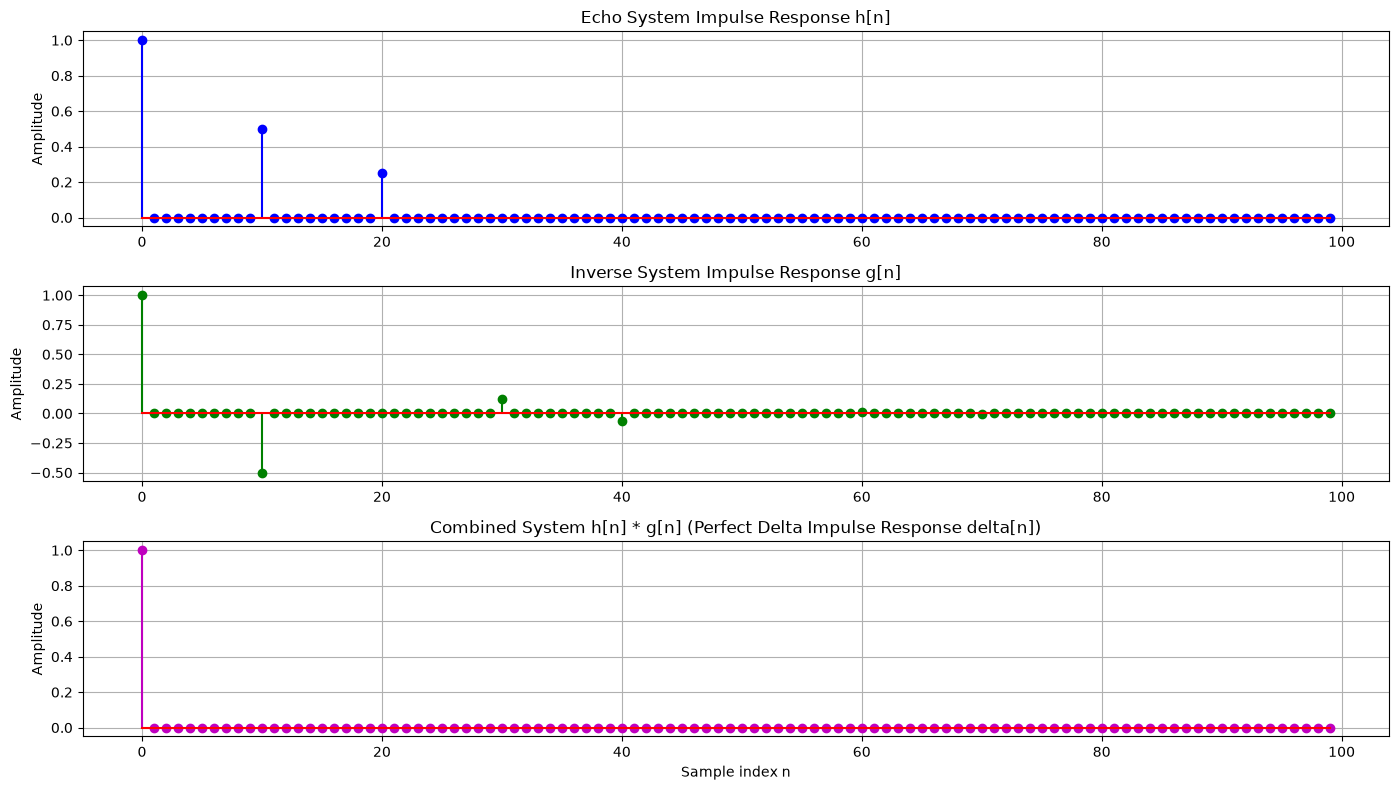

In [8]:
D = 10  # delay parameter
N = 100

# Construct h[n]
h = np.zeros(N)
h[0] = 1.0
h[D] = 0.5
h[2 * D] = 0.25

# Construct g[n] using the computed b_k
g = np.zeros(N)
for k in range(K):
    if k * D < N:
        g[k * D] = b[k]

# Convolve h[n] with g[n]
c = np.convolve(h, g)[:N]

plt.figure(figsize=(14, 8))

plt.subplot(3, 1, 1)
plt.stem(np.arange(N), h, linefmt='b-', markerfmt='bo', basefmt='r-')
plt.title('Echo System Impulse Response h[n]')
plt.ylabel('Amplitude')
plt.grid(True)

plt.subplot(3, 1, 2)
plt.stem(np.arange(N), g, linefmt='g-', markerfmt='go', basefmt='r-')
plt.title('Inverse System Impulse Response g[n]')
plt.ylabel('Amplitude')
plt.grid(True)

plt.subplot(3, 1, 3)
plt.stem(np.arange(N), c, linefmt='m-', markerfmt='mo', basefmt='r-')
plt.title('Combined System h[n] * g[n] (Perfect Delta Impulse Response delta[n])')
plt.xlabel('Sample index n')
plt.ylabel('Amplitude')
plt.grid(True)

plt.tight_layout()
plt.show()
